In [1]:
import numpy as np
import numpy.ma as ma
import xarray as xr
import xcdat
import matplotlib.pyplot as plt
import os
import re
import glob

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/b/beharrop/.conda/envs/myenv2/share/proj failed


## Functions for reading in observations and model data

In [2]:
def read_observations(path, normyr):

  # --- HadCRUT5-Analysis ---
  region = ['gl', 'nh', 'sh']
  nregions = len(region)
  for r in range(nregions):
    tmp_year = []
    tmp_tas = []
    f = open('%s/HadCRUT5-Analysis/HadCRUT5.0Analysis_%s.txt' % (path,region[r]), 'r')
    line = f.readline()
    while line:
      tmp = line.split()
      tmp_year.append(int(tmp[0]))
      tmp_tas.append(float(tmp[13]))
      line = f.readline()
      line = f.readline()
    f.close()
    if r == 0:
        year = np.array(tmp_year)
        nyears = len(year)
        tas = ma.zeros( (nyears,nregions), 'float64')
    tas[:,r] = np.array(tmp_tas)

  # --- Optionally normalize ---
  if normyr is not None:
      i1 = (np.abs(year-normyr[0])).argmin()
      i2 = (np.abs(year-normyr[1])).argmin()
      print("Normalizing observations")
      print(year[i1:i2+1])
      for r in range(len(region)):
          tas[:,r] = tas[:,r] - np.average(tas[i1:i2+1,r])
  else:
      # Add absolute means if not normalizing
      f = open('%s/HadCRUT5-Analysis/abs_glnhsh.txt' % (path), 'r')
      line = f.readline()
      while not line.startswith("Annual "):
          line = f.readline()
      tmp = line.split()[1:]
      absolute = np.array([float(n) for n in tmp]) 
      print("Adding absolute to observations anomalies")
      print(absolute)
      for r in range(len(region)):
          tas[:,r] = tas[:,r] + absolute[r]

  # Copy to dictionary
  obs = ({'name':'HadCRUT5-Analysis', 'nyears':nyears, 'nregions':nregions,
            'year':np.copy(year), 'tas':np.copy(tas)})

  return obs

In [3]:
def read_E3SM(name, files, normyr=None):

  nmembers = len(files)

  # --- Read data from csv files ---
  first = True
  for m in range(nmembers):

      print("Reading %s" % files[m])
      data = np.loadtxt(files[m], delimiter=',')

      # years and number of regions based on first member
      if first:
          nregions = np.shape(data)[1] - 1
          year = data[:,0]
          nyears = len(year)
          tas = np.zeros([nyears,nregions,nmembers])
          first = False
  
      # copy
      tas[:,:,m] = data[:,1:]

  # --- Optionally normalize ---
  if normyr is not None:
      i1 = (np.abs(year-normyr[0])).argmin()
      i2 = (np.abs(year-normyr[1])).argmin()
      print("Normalizing %s" % name)
      print(year[i1:i2+1])
      for r in range(nregions):
          for m in range(nmembers):
              tas[:,r,m] = tas[:,r,m] - np.average(tas[i1:i2+1,r,m])
  else:
      # Convert to deg Celsius if not normalizing
      tas = tas - 273.15

  # --- Compute ensemble mean, mix, max ---
  tas_ens = np.zeros([nyears,nregions,3])
  tas_ens[:,:,0] = np.average(tas, axis=2)
  tas_ens[:,:,1] = np.amin(tas, axis=2)
  tas_ens[:,:,2] = np.amax(tas, axis=2)

  # Copy to dictionary
  model = ({'name':name, 'nyears':nyears, 'nregions':nregions, 'nmembers':nmembers,
            'year':np.copy(year), 'tas':np.copy(tas), 'tas_ens':np.copy(tas_ens)})

  return model

def read_E3SM_single(name, files, normyr=None):

  print("Reading %s" % files[0])
  data = np.loadtxt(files[0], delimiter=',')
  year = data[:,0]
  nyears = len(year)
  tas  = data[:,2]

  if normyr is not None:
    i1 = (np.abs(year-normyr[0])).argmin()
    i2 = (np.abs(year-normyr[1])).argmin()
    print("Normalizing %s" % name)
    print(year[i1:i2+1])
    tas = tas - np.average(tas[i1:i2+1])
  else:
    tas = tas - 273.15

  model = ({'name':name, 'nyears':nyears, 'nregions':1, 'nmembers':1,
            'year':np.copy(year), 'tas':np.copy(tas)})

  return model

## Read in the Data

In [4]:
# --- Normalize ---
normyr = (1850,1899)
#normyr = (1951,1980)
#normyr = None

# --- E3SMv1 ---
E3SMv1_files = [
'E3SMv1/v1.LR.historical_H1.csv',
'E3SMv1/v1.LR.historical_H2.csv',
'E3SMv1/v1.LR.historical_H3.csv',
'E3SMv1/v1.LR.historical_H4.csv',
'E3SMv1/v1.LR.historical_H5.csv',
]
v1 = read_E3SM('E3SMv1', E3SMv1_files, normyr)

# --- E3SMv2 ---
E3SMv2_files = [
'E3SMv2/v2.LR.historical_0101.csv',
'E3SMv2/v2.LR.historical_0151.csv',
'E3SMv2/v2.LR.historical_0201.csv',
'E3SMv2/v2.LR.historical_0251.csv',
'E3SMv2/v2.LR.historical_0301.csv',
]
v2 = read_E3SM('E3SMv2', E3SMv2_files, normyr)

XLE_members = ['0051', '0091', '0101', '0111', '0121',
               '0131', '0141', '0151', '0161', '0171',
               '0181', '0191', '0201', '0211', '0221',
               '0231', '0241', '0251', '0261', '0271',
               '0281', '0291', '0301', '0311', '0321',
              ]
               
# --- E3SMv3 ---
E3SMv3_files = [f'E3SMv3/v3.LR.historical_{ens}.csv' for ens in XLE_members]
v3 = read_E3SM('E3SMv3 default', E3SMv3_files, normyr)

# --- E3SMv3 lowECS ---
E3SMv3_lowECS_files = [f'E3SMv3.lowECS/v3.LR.lowECS.historical_{ens}.csv' for ens in XLE_members]
v3_lowECS = read_E3SM('E3SMv3 lowECS', E3SMv3_lowECS_files, normyr)

# --- E3SMv3 highECS ---
E3SMv3_highECS_files = [f'E3SMv3.highECS/v3.LR.highECS.historical_{ens}.csv' for ens in XLE_members]
v3_highECS = read_E3SM('E3SMv3 highECS', E3SMv3_highECS_files, normyr)

# --- Observations ---
obs = read_observations('OBS', normyr)

Reading E3SMv1/v1.LR.historical_H1.csv
Reading E3SMv1/v1.LR.historical_H2.csv
Reading E3SMv1/v1.LR.historical_H3.csv
Reading E3SMv1/v1.LR.historical_H4.csv
Reading E3SMv1/v1.LR.historical_H5.csv
Normalizing E3SMv1
[1850. 1851. 1852. 1853. 1854. 1855. 1856. 1857. 1858. 1859. 1860. 1861.
 1862. 1863. 1864. 1865. 1866. 1867. 1868. 1869. 1870. 1871. 1872. 1873.
 1874. 1875. 1876. 1877. 1878. 1879. 1880. 1881. 1882. 1883. 1884. 1885.
 1886. 1887. 1888. 1889. 1890. 1891. 1892. 1893. 1894. 1895. 1896. 1897.
 1898. 1899.]
Reading E3SMv2/v2.LR.historical_0101.csv
Reading E3SMv2/v2.LR.historical_0151.csv
Reading E3SMv2/v2.LR.historical_0201.csv
Reading E3SMv2/v2.LR.historical_0251.csv
Reading E3SMv2/v2.LR.historical_0301.csv
Normalizing E3SMv2
[1850. 1851. 1852. 1853. 1854. 1855. 1856. 1857. 1858. 1859. 1860. 1861.
 1862. 1863. 1864. 1865. 1866. 1867. 1868. 1869. 1870. 1871. 1872. 1873.
 1874. 1875. 1876. 1877. 1878. 1879. 1880. 1881. 1882. 1883. 1884. 1885.
 1886. 1887. 1888. 1889. 1890. 1891. 

In [5]:
XLE_root = '/global/cfs/cdirs/e3smdata/simulations/v3.XLE'

def read_XLE_glb(case_template, var='TREFHT', members=XLE_members):
    """Load global-mean monthly timeseries for all ensemble members into one Dataset."""

    paths = []
    for ens in members:
        case = case_template.format(ens=ens)
        # zero-padded dates make the lexical sort chronological
        member_files = sorted(glob.glob(
            f'{XLE_root}/{case}/post/atm/glb/ts/monthly/5yr/{var}_*.nc'))
        if not member_files:
            raise FileNotFoundError(f'No {var} files found for {case}')
        paths.append(member_files)

    nfiles = {len(p) for p in paths}
    if len(nfiles) > 1:
        counts = {m: len(p) for m, p in zip(members, paths)}
        raise ValueError(f'Uneven number of {var} files across members: {counts}')

    print(f'Reading {var} for {len(members)} members x {len(paths[0])} files: {case_template}')
    ds = xr.open_mfdataset(paths,
                           combine='nested',
                           concat_dim=['ensemble', 'time'],
                           data_vars='all',
                           coords='minimal',
                           compat='override',
                           join='override',
                           parallel=True)

    # glb files are already area-averaged, so drop any leftover length-1 spatial dims
    squeeze_dims = [d for d in ('lat', 'lon', 'ncol') if ds.sizes.get(d) == 1]
    if squeeze_dims:
        ds = ds.squeeze(squeeze_dims, drop=True)

    return ds.assign_coords(ensemble=list(members))


tas_v3         = read_XLE_glb('v3.LR.historical_{ens}')
tas_v3_lowECS  = read_XLE_glb('v3.LR.lowECS.historical_{ens}')
tas_v3_highECS = read_XLE_glb('v3.LR.highECS.historical_{ens}')

print(tas_v3)


Reading TREFHT for 25 members x 35 files: v3.LR.historical_{ens}
Reading TREFHT for 25 members x 35 files: v3.LR.lowECS.historical_{ens}
Reading TREFHT for 25 members x 35 files: v3.LR.highECS.historical_{ens}
<xarray.Dataset> Size: 1MB
Dimensions:      (ensemble: 25, time: 2100, rgn: 3, nbnd: 2)
Coordinates:
  * ensemble     (ensemble) <U4 400B '0051' '0091' '0101' ... '0311' '0321'
  * time         (time) object 17kB 1850-02-01 00:00:00 ... 2025-01-01 00:00:00
    region_name  (rgn) |S19 57B dask.array<chunksize=(3,), meta=np.ndarray>
Dimensions without coordinates: rgn, nbnd
Data variables:
    TREFHT       (ensemble, time, rgn) float32 630kB dask.array<chunksize=(1, 60, 3), meta=np.ndarray>
    time_bnds    (ensemble, time, nbnd) object 840kB dask.array<chunksize=(1, 60, 2), meta=np.ndarray>
Attributes: (12/20)
    ne:                30
    fv_nphys:          2
    title:             EAM History file information
    source:            E3SM Atmosphere Model
    source_id:         39

In [6]:
def add_time_bnds(ds):
    """
    Add a time_bnds variable to a dataset whose time coordinate represents
    the right bound of each monthly interval (i.e., first day of the following
    month).  The left bound is set to the first day of the current month at
    00:00:00, matching the E3SM convention.
    """
    times = ds["time"].values

    def left_bound(dt):
        year, month = dt.year, dt.month - 1
        if month == 0:
            month, year = 12, year - 1
        return type(dt)(year, month, 1, 0, 0, 0, 0, has_year_zero=dt.has_year_zero)

    left_bnds  = np.array([left_bound(t) for t in times])
    right_bnds = times

    time_bnds = xr.DataArray(
        np.array(list(zip(left_bnds, right_bnds))),
        dims=["time", "bnds"],
        coords={"time": ds["time"]},
    )
    ds = ds.assign({"time_bnds": time_bnds})
    ds["time"].attrs["bounds"] = "time_bnds"
    return ds

tas_v3         = xcdat.center_times(add_time_bnds(tas_v3))
tas_v3_lowECS  = xcdat.center_times(add_time_bnds(tas_v3_lowECS))
tas_v3_highECS = xcdat.center_times(add_time_bnds(tas_v3_highECS))

In [7]:
def annual_day_weighted_mean(ds_in, data_var="tas", weighted=True):
    return ds_in.temporal.group_average(data_var, freq="year", weighted=weighted)

tas_v3_annual         = annual_day_weighted_mean(tas_v3,         data_var='TREFHT')
tas_v3_lowECS_annual  = annual_day_weighted_mean(tas_v3_lowECS,  data_var='TREFHT')
tas_v3_highECS_annual = annual_day_weighted_mean(tas_v3_highECS, data_var='TREFHT')

In [8]:
def normalize_tas(ds, normyr, data_var='TREFHT', name=''):
    ds = ds.copy()
    if normyr is not None:
        years = ds['time'].dt.year
        mask = (years >= normyr[0]) & (years <= normyr[1])
        print("Normalizing %s" % name)
        print(ds['time'].where(mask, drop=True).values)
        baseline = ds[data_var].where(mask, drop=True).mean('time')
        ds[data_var] = ds[data_var] - baseline
    else:
        # Convert to deg Celsius if not normalizing
        ds[data_var] = ds[data_var] - 273.15
    return ds


tas_v3_annual         = normalize_tas(tas_v3_annual,         normyr, name='E3SMv3 default')
tas_v3_lowECS_annual  = normalize_tas(tas_v3_lowECS_annual,  normyr, name='E3SMv3 lowECS')
tas_v3_highECS_annual = normalize_tas(tas_v3_highECS_annual, normyr, name='E3SMv3 highECS')

tas_v3_ann_ens         = tas_v3_annual.mean('ensemble').compute()
tas_v3_lowECS_ann_ens  = tas_v3_lowECS_annual.mean('ensemble').compute()
tas_v3_highECS_ann_ens = tas_v3_highECS_annual.mean('ensemble').compute()

Normalizing E3SMv3 default
[cftime.DatetimeNoLeap(1850, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1851, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1852, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1853, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1854, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1855, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1856, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1857, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1858, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1859, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1860, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1861, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1862, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1863, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1864, 1, 1, 

In [9]:
CMIP6_data_dir = '/global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/'

# --- Group CSV files by model name (e.g. "ACCESS-CM2_r3_incomplete.csv" -> model="ACCESS-CM2", realization=3) ---
model_files = {}
for f in sorted(glob.glob(os.path.join(CMIP6_data_dir, '*.csv'))):
    basename = os.path.splitext(os.path.basename(f))[0]
    match = re.match(r'^(.+)_r(\d+)(?:_incomplete)?$', basename)
    if not match:
        print("Skipping unrecognized file: %s" % basename)
        continue
    model_name, realization = match.group(1), int(match.group(2))
    model_files.setdefault(model_name, []).append((realization, f))

# --- Read data for each model, using read_E3SM for multi-realization and read_E3SM_single otherwise ---
cmip6_models = {}
for model_name, files in model_files.items():
    if 'E3SM' in model_name.upper():
        continue
    files_sorted = [f for _, f in sorted(files)]
    if len(files_sorted) > 1:
        cmip6_models[model_name] = read_E3SM(model_name, files_sorted, normyr)
    else:
        cmip6_models[model_name] = read_E3SM_single(model_name, files_sorted, normyr)


Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r1.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r2.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r3.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r4.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r5.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r6.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r7.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/analysis_scripts/E3SMv3-XLE-analysis/hist_plot/CMIP6_csv/ACCESS-CM2_r8.csv
Reading /global/cfs/cdirs/e3sm/beharrop/XLE/anal

## Generate figures

In [10]:
figure_dir = '/pscratch/sd/b/beharrop/E3SMv3/XLE/figures/'

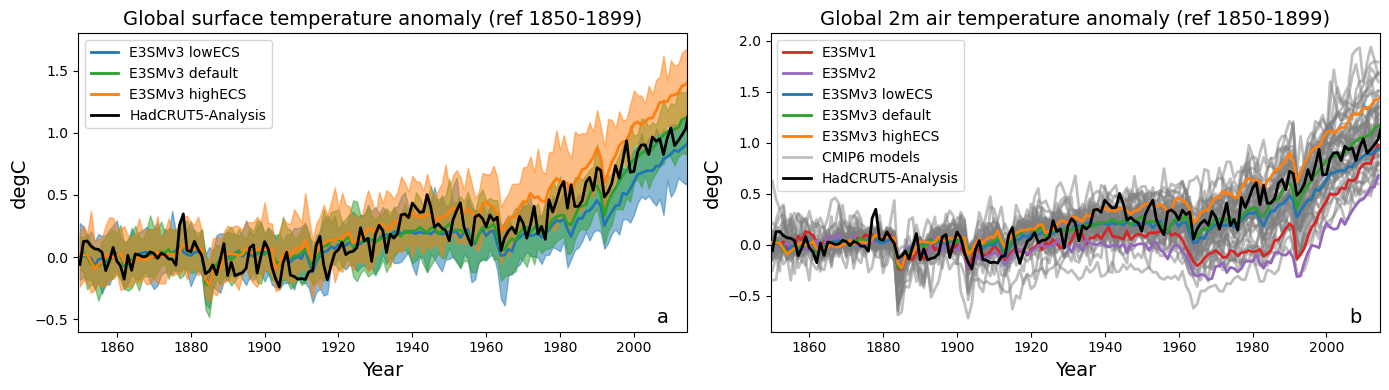

In [11]:
# --- Generate plot ---
xlim = [1849.5, 2014.5]
ylim = [-0.6,1.8]

region = ['Global']
for r in range(len(region)):

    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=[14.0, 4.0])
    for ax in axs:
        ax.set_xlim(xlim)
    axs[0].set_ylim(ylim)

    # Plot details
    alpha     = 0.5
    linewidth = 2.0
    fontsize  = 14

    # E3SMv3 lowECS ensemble
    axs[0].fill_between(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,1], v3_lowECS['tas_ens'][:,r,2], 
                        color='tab:blue', alpha=alpha)
    axs[0].plot(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,0], 
                linewidth=linewidth, color='tab:blue', label=v3_lowECS['name'], alpha=1)

    # E3SMv3 default ensemble
    axs[0].fill_between(v3['year'], v3['tas_ens'][:,r,1], v3['tas_ens'][:,r,2], 
                        color='tab:green', alpha=alpha)
    axs[0].plot(v3['year'], v3['tas_ens'][:,r,0], 
                linewidth=linewidth, color='tab:green', label=v3['name'], alpha=1)

    # E3SMv3 highECS ensemble
    axs[0].fill_between(v3_highECS['year'], v3_highECS['tas_ens'][:,r,1], v3_highECS['tas_ens'][:,r,2], 
                        color='tab:orange', alpha=alpha)
    axs[0].plot(v3_highECS['year'], v3_highECS['tas_ens'][:,r,0], 
                linewidth=linewidth, color='tab:orange', label=v3_highECS['name'], alpha=1)

    # Observations
    axs[0].plot(obs['year'], obs['tas'][:,r], 
                linewidth=linewidth, color='k', label=obs['name'], alpha=1)

    if normyr is None:
        axs[0].set_title(f"{region[r]} surface temperature", fontsize=fontsize)
    else:
        axs[0].set_title(f"{region[r]} surface temperature anomaly (ref {normyr[0]}-{normyr[1]})", 
                         fontsize=fontsize)
    axs[0].set_xlabel("Year", fontsize=fontsize)
    axs[0].set_ylabel("degC", fontsize=fontsize)
    axs[0].legend(loc="best")

    ##############################################################################################

    # E3SMv1 ensemble
    axs[1].plot(v1['year'], v1['tas_ens'][:,r,0],
            linewidth=linewidth, color='tab:red', label=v1['name'], alpha=1, zorder=2)

    # E3SMv2 ensemble
    axs[1].plot(v2['year'],v2['tas_ens'][:,r,0],
            linewidth=linewidth, color='tab:purple', label=v2['name'], alpha=1, zorder=2)

    # E3SMv3 lowECS ensemble
    # axs[1].plot(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,0], 
    #         linewidth=linewidth, c='tab:blue', label=v3_lowECS['name'], alpha=1, zorder=3)
    axs[1].plot(tas_v3_lowECS_ann_ens['time'].dt.year, tas_v3_lowECS_ann_ens['TREFHT'].isel(rgn=r),
                linewidth=linewidth, c='tab:blue', label=v3_lowECS['name'], alpha=1, zorder=3)

    # E3SMv3 default ensemble
    # axs[1].plot(v3['year'], v3['tas_ens'][:,r,0], 
    #         linewidth=linewidth, color='tab:green', label=v3['name'], alpha=1, zorder=3)
    axs[1].plot(tas_v3_ann_ens['time'].dt.year, tas_v3_ann_ens['TREFHT'].isel(rgn=r),
                    linewidth=linewidth, c='tab:green', label=v3['name'], alpha=1, zorder=3)

    # E3SMv3 highECS ensemble
    # axs[1].plot(v3_highECS['year'], v3_highECS['tas_ens'][:,r,0], 
    #         linewidth=linewidth, color='tab:orange', label=v3_highECS['name'], alpha=1, zorder=3)
    axs[1].plot(tas_v3_highECS_ann_ens['time'].dt.year, tas_v3_highECS_ann_ens['TREFHT'].isel(rgn=r),
                    linewidth=linewidth, c='tab:orange', label=v3_highECS['name'], alpha=1, zorder=3)

    for model in cmip6_models:
        if cmip6_models[model]['nmembers'] == 1:
            if model == 'SAM0-UNICON':
                axs[1].plot(cmip6_models[model]['year'], cmip6_models[model]['tas'], 
                        linewidth=linewidth, color='tab:gray', label='CMIP6 models', alpha=alpha, zorder=1)
            else:
                axs[1].plot(cmip6_models[model]['year'], cmip6_models[model]['tas'], 
                        linewidth=linewidth, color='tab:gray', alpha=alpha, zorder=1)
        else:
            axs[1].plot(cmip6_models[model]['year'], cmip6_models[model]['tas_ens'][:,r,0], 
                    linewidth=linewidth, color='tab:gray', alpha=alpha, zorder=1)

    # Observations
    axs[1].plot(obs['year'], obs['tas'][:,r], ls='solid', 
                lw=linewidth, color='k', label=obs['name'], alpha=1, zorder=3)

    if normyr is None:
        axs[1].set_title(f"{region[r]} 2m air temperature", fontsize=fontsize)
    else:
        axs[1].set_title(f"{region[r]} 2m air temperature anomaly (ref {normyr[0]}-{normyr[1]})",
                         fontsize=fontsize)
    axs[1].set_xlabel("Year", fontsize=fontsize)
    axs[1].set_ylabel("degC", fontsize=fontsize)
    axs[1].legend(loc="best")

    for ax, letter in zip(axs, ['a', 'b']):
        ax.text(0.95, 0.08, f"{letter}", transform=ax.transAxes, fontsize=fontsize, va='top')

    fig.tight_layout()
    fig.savefig(f"{figure_dir}ts_tas_{region[r]}.pdf")
    fig.savefig(f"{figure_dir}ts_tas_{region[r]}.png", dpi=300)
plt.show()

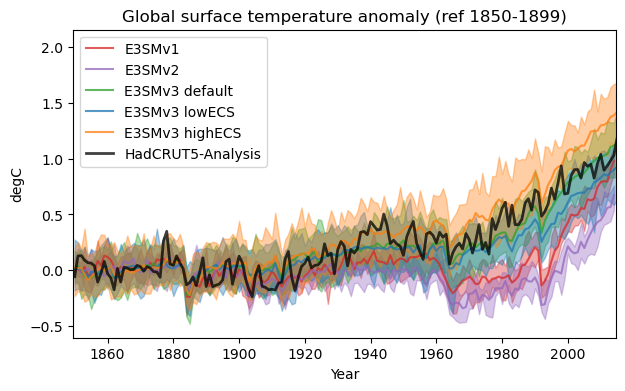

In [12]:
# --- Generate plot ---
xlim = [1849.5, 2014.5]
ylim = [-0.5,1.5]

region = ['Global']#, 'NH', 'SH']
for r in range(len(region)):

    fig = plt.figure(figsize=[7.0, 4.0])
    ax = plt.subplot(1, 1, 1)
    ax.set_xlim(xlim)
    #ax.set_ylim(ylim)

    # Transparency
    a = 0.75

    # E3SMv1 ensemble
    ax.fill_between(v1['year'], v1['tas_ens'][:,r,1], v1['tas_ens'][:,r,2],
                    color='tab:red', alpha=0.5 * a)
    ax.plot(v1['year'], v1['tas_ens'][:,r,0],
            lw=1.5, c='tab:red', label=v1['name'], alpha=a)

    # E3SMv2 ensemble
    ax.fill_between(v2['year'], v2['tas_ens'][:,r,1], v2['tas_ens'][:,r,2],
                    color='tab:purple', alpha=0.5 * a)
    ax.plot(v2['year'],v2['tas_ens'][:,r,0],
            lw=1.5, c='tab:purple', label=v2['name'], alpha=a)

    # E3SMv3 default ensemble
    ax.fill_between(v3['year'], v3['tas_ens'][:,r,1], v3['tas_ens'][:,r,2], 
                    color='tab:green', alpha=0.5 * a)
    ax.plot(v3['year'], v3['tas_ens'][:,r,0], 
            lw=1.5, c='tab:green', label=v3['name'], alpha=a)

    # E3SMv3 lowECS ensemble
    ax.fill_between(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,1], v3_lowECS['tas_ens'][:,r,2], 
                    color='tab:blue', alpha=0.5 * a)
    ax.plot(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,0], 
            lw=1.5, c='tab:blue', label=v3_lowECS['name'], alpha=a)

    # E3SMv3 highECS ensemble
    ax.fill_between(v3_highECS['year'], v3_highECS['tas_ens'][:,r,1], v3_highECS['tas_ens'][:,r,2], 
                    color='tab:orange', alpha=0.5 * a)
    ax.plot(v3_highECS['year'], v3_highECS['tas_ens'][:,r,0], 
            lw=1.5, c='tab:orange', label=v3_highECS['name'], alpha=a)

    # Observations
    ax.plot(obs['year'], obs['tas'][:,r], ls='solid', lw=2.0, color='k', label=obs['name'], alpha=a)

    if normyr is None:
        ax.set_title(f"{region[r]} surface temperature", loc="right")
    else:
        ax.set_title(f"{region[r]} surface temperature anomaly (ref {normyr[0]}-{normyr[1]})")
    ax.set_xlabel("Year")
    ax.set_ylabel("degC")
    ax.legend(loc="best")

    # fig.savefig("ts_tas_%s.pdf" % (region[r]))
    # fig.savefig("ts_tas_%s.png" % (region[r]), dpi=200)
    # plt.clf(

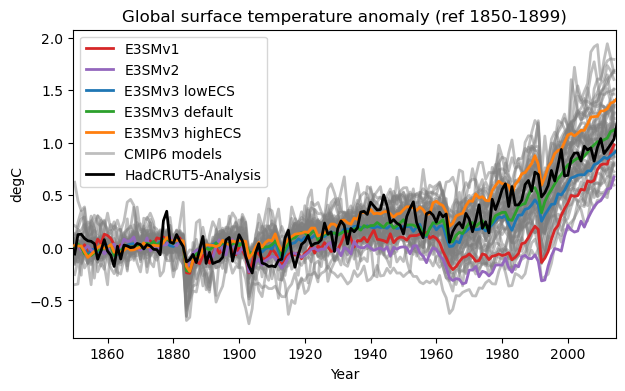

In [13]:
# --- Generate plot ---
xlim = [1849.5, 2014.5]
ylim = [-0.5,1.5]

region = ['Global']#, 'NH', 'SH']
for r in range(len(region)):

    fig = plt.figure(figsize=[7.0, 4.0])
    ax = plt.subplot(1, 1, 1)
    ax.set_xlim(xlim)
    #ax.set_ylim(ylim)

    # Transparency
    a = 0.5
    linewidth = 2

    # E3SMv1 ensemble
    # ax.fill_between(v1['year'], v1['tas_ens'][:,r,1], v1['tas_ens'][:,r,2],
    #                 color='tab:red', alpha=a, zorder=2)
    ax.plot(v1['year'], v1['tas_ens'][:,r,0],
            lw=linewidth, c='tab:red', label=v1['name'], alpha=1, zorder=2)

    # E3SMv2 ensemble
    # ax.fill_between(v2['year'], v2['tas_ens'][:,r,1], v2['tas_ens'][:,r,2],
    #                 color='tab:purple', alpha=a, zorder=2)
    ax.plot(v2['year'],v2['tas_ens'][:,r,0],
            lw=linewidth, c='tab:purple', label=v2['name'], alpha=1, zorder=3)

    # E3SMv3 lowECS ensemble
    # ax.fill_between(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,1], v3_lowECS['tas_ens'][:,r,2], 
    #                 color='tab:blue', alpha=a, zorder=2)
    ax.plot(v3_lowECS['year'], v3_lowECS['tas_ens'][:,r,0], 
            lw=linewidth, c='tab:blue', label=v3_lowECS['name'], alpha=1, zorder=2)

    # E3SMv3 default ensemble
    # ax.fill_between(v3['year'], v3['tas_ens'][:,r,1], v3['tas_ens'][:,r,2], 
    #                 color='tab:green', alpha=a, zorder=2)
    ax.plot(v3['year'], v3['tas_ens'][:,r,0], 
            lw=linewidth, c='tab:green', label=v3['name'], alpha=1, zorder=3)

    # E3SMv3 highECS ensemble
    # ax.fill_between(v3_highECS['year'], v3_highECS['tas_ens'][:,r,1], v3_highECS['tas_ens'][:,r,2], 
    #                 color='tab:orange', alpha=a, zorder=2)
    ax.plot(v3_highECS['year'], v3_highECS['tas_ens'][:,r,0], 
            lw=linewidth, c='tab:orange', label=v3_highECS['name'], alpha=1, zorder=3)

    for model in cmip6_models:
        if cmip6_models[model]['nmembers'] == 1:
            if model == 'SAM0-UNICON':
                ax.plot(cmip6_models[model]['year'], cmip6_models[model]['tas'], 
                        lw=linewidth, c='tab:gray', label='CMIP6 models', alpha=0.5, zorder=1)
            else:
                ax.plot(cmip6_models[model]['year'], cmip6_models[model]['tas'], 
                        lw=linewidth, c='tab:gray', alpha=0.5, zorder=1)
        else:
            # ax.fill_between(cmip6_models[model]['year'], 
            #                 cmip6_models[model]['tas_ens'][:,r,1], 
            #                 cmip6_models[model]['tas_ens'][:,r,2], 
            #                 color='tab:gray', alpha=0.1, zorder=1)
            ax.plot(cmip6_models[model]['year'], cmip6_models[model]['tas_ens'][:,r,0], 
                    lw=linewidth, c='tab:gray', alpha=0.5, zorder=1)

    # Observations
    ax.plot(obs['year'], obs['tas'][:,r], ls='solid', lw=linewidth, color='k', label=obs['name'], alpha=1, zorder=3)

    if normyr is None:
        ax.set_title(f"{region[r]} surface temperature", loc="right")
    else:
        ax.set_title(f"{region[r]} surface temperature anomaly (ref {normyr[0]}-{normyr[1]})")
    ax.set_xlabel("Year")
    ax.set_ylabel("degC")
    ax.legend(loc="best")

    # fig.savefig("ts_tas_%s.pdf" % (region[r]))
    # fig.savefig("ts_tas_%s.png" % (region[r]), dpi=200)
    # plt.clf()